# Predicting Hourly Bitcoin Return Direction
#### A multi-model study of directional predictability and algorithmic trading on BTC/USD

**Team**
- Agata Juda - Team Leader
- Dominik Hołoś - Data Engineer
- Weronika Jaszkiewicz - Modeler
- Alicja Górnik - Analyst

**Course:** Machine Learning for Data Analytics

---
This notebook is the **standalone narrative** of the project: it can be read on its
own, top to bottom, and tells the full story *problem -> data -> methods -> results ->
interpretation -> impact*. The detailed implementation lives in notebooks 01–04; here
we load the saved artifacts and present the findings.

## Executive summary

| | |
|---|---|
| **Question** | Can the **direction of the next hourly BTC/USD return** be predicted from recent market history? |
| **Data** | Kaggle minute-level BTC/USD, year **2025**, resampled hourly (8,760 obs), 25 leakage-free features |
| **Models** | Baseline · ARIMA · GARCH · Random Forest · XGBoost · LSTM · PPO & CEM trading agents |
| **Best classifier** | Random Forest, **ROC-AUC 0.527** - only ~0.008 above the stratified baseline (0.519) |
| **Forecasters** | Direction accuracy **45.8–47.9%** (below 50%) |
| **Trading** | No strategy beats Buy & Hold on a **risk-adjusted** basis (all Sharpe < 0) |
| **Headline** | **No reliable directional edge at the hourly horizon** - consistent with a near-efficient market, and a credible result in its own right |
| **Engineering** | 5-notebook pipeline, **MLflow** experiment tracking, reproducible file-saved models, fixed seeds |

The value of this project is a **rigorous, honest negative result** plus a fully reproducible MLOps pipeline - not an over-claimed "we beat the market".

## 1. Introduction & motivation

We ask a deliberately hard question: **can the direction of the next hour's Bitcoin
return be predicted from recent market history?** We frame it as binary classification
- will the next hourly log-return be positive? - and, as a second objective, let
reinforcement-learning agents (PPO and CEM) turn any signal into a simple long/flat
trading policy.

The problem **matters** because, in hourly crypto trading, even a small but reliable
directional edge would be valuable. It is **hard** because liquid markets are close to
*efficient* at this frequency: past returns carry very little exploitable information
about future ones. That tension is the whole point - rather than assume an edge exists,
we test for one with a broad set of models from different course modules, and then ask
the only question that ultimately matters: **would any edge survive a realistic
backtest, net of the market's own movement?**

## 2. Setup - load saved artifacts

In [1]:
from pathlib import Path

PROJECT_ROOT   = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
REPORTS_DIR    = PROJECT_ROOT / "reports"
for _d in (DATA_PROCESSED, MODELS_DIR, REPORTS_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Użytkownik\Desktop\studia\magisterka\Machine learning\Project\MLDA - checking


In [2]:
import pandas as pd, json
import matplotlib.pyplot as plt

with open(DATA_PROCESSED / "metadata.json") as f:
    meta = json.load(f)
metrics_table  = pd.read_csv(REPORTS_DIR / "metrics_table.csv",  index_col=0)
backtest_table = pd.read_csv(REPORTS_DIR / "backtest_table.csv", index_col=0)
print("Artifacts loaded.")

Artifacts loaded.


## 3. Data & EDA highlights

The data is Kaggle's minute-level **BTC/USD** history (`mczielinski/bitcoin-historical-data`),
downloaded programmatically. We restrict to the full year **2025**, resample to **hourly**
bars (8,760 hours; price range ≈ 74.7k–126.1k USD), and engineer **25 leakage-free
features** in four families: lagged log-returns (1–10), rolling mean/std and absolute-mean
(windows 3/7/14), momentum (3/7/14), and volatility proxies. The target is the sign of the
*next* hour's return, defined with `shift(-1)` so no future information leaks in.

EDA established the facts that shape every modelling choice downstream:

- **Returns are tiny and centred on zero** (mean ≈ 0, hourly std ≈ 0.48%) - the price level trends, but the returns we must predict barely do.
- **Strongly non-Gaussian:** excess kurtosis ≈ 14, slight negative skew (−0.18) - fat tails dominate, motivating GARCH and robust learners.
- **Volatility clusters** (clear in the absolute-return and rolling-σ plots and the ACF of squared returns), even though the returns themselves are nearly uncorrelated.
- **Returns are stationary** (ADF p < 0.0001 *and* KPSS p > 0.10 agree) -> ARIMA uses d = 0.
- **The target is balanced** (~50.4% up / 49.6% down) → accuracy alone is uninformative; we judge models by **ROC-AUC** and **F1**.

In [3]:
print(f"Window    : {meta['start_date']} -> {meta['end_date']}")
print(f"Frequency : {meta['frequency']}")
print(f"Features  : {len(meta['feature_cols'])}")
print(f"Target    : {meta['target']} (1 = next-hour return > 0)")
print(f"Seed      : {meta['random_seed']}")

Window    : 2025-01-01 -> 2026-01-01
Frequency : 1h
Features  : 25
Target    : target (1 = next-hour return > 0)
Seed      : 47


## 4. Methods

The project deliberately spans several course modules:

| Module | Model(s) | Why it fits this problem |
|--------|----------|--------------------------|
| Baseline | DummyClassifier (stratified) | the floor every model must clear |
| Classical time series | ARIMA (returns), GARCH (volatility) | EDA showed stationary returns (d = 0) and volatility clustering |
| Tree ensembles | Random Forest, XGBoost | robust to correlated, non-linear features; no distributional assumptions |
| Deep learning | LSTM over 20-hour sequences | tests whether temporal structure helps beyond static features |
| Reinforcement learning | PPO, CEM trading agents | convert predictions into an actual long/flat policy |
| Bayesian / uncertainty | MC-Dropout + ECE | quantify *when* to trust a prediction |
| Interpretability | SHAP (global + local) | explain *why* the models predict what they do |
| MLOps | MLflow + reproducible saved models | track every experiment; reproduce from scratch |

## 5. Time-series forecasting results

We fit the classical and ML forecasters on the stationary **log-return** series and compare
them on a 48-hour **rolling 1-step** basis. ARIMA's order was chosen by AIC - ARIMA(3,0,2);
GARCH(2,3) models the volatility. Because hourly returns are near white noise, the ARIMA
*return* forecast collapses to the mean (a flat line); presented on the **price scale**
(`price_hat = last_price × exp(return_forecast)`) it tracks the actual price - the same
honest conclusion seen two ways: **BTC behaves like a random walk at this horizon.**

In [4]:
ts_comparison = pd.DataFrame(
    [["Random Forest",     0.003622, 47.92],
     ["ARIMA(3,0,2)",      0.003640, 45.83],
     ["Prophet",           0.003695, None],
     ["Gradient Boosting", 0.003798, 47.92]],
    columns=["Model", "RMSE", "Direction %"]).set_index("Model")
print(ts_comparison)
print("\nGARCH(2,3): volatility model (no point forecast of returns).")
print("Note: every forecaster scores BELOW 50% on direction -- no usable sign signal.")
ts_comparison

                       RMSE  Direction %
Model                                   
Random Forest      0.003622        47.92
ARIMA(3,0,2)       0.003640        45.83
Prophet            0.003695          NaN
Gradient Boosting  0.003798        47.92

GARCH(2,3): volatility model (no point forecast of returns).
Note: every forecaster scores BELOW 50% on direction -- no usable sign signal.


,RMSE,Direction %
Model,,
Random Forest,0.003622,47.92
"ARIMA(3,0,2)",0.003640,45.83
Prophet,0.003695,NaN
Gradient Boosting,0.003798,47.92


## 6. Classification results

All four classifiers land just above chance. The leaderboard below and the ROC-AUC chart
make the (lack of) separation visible.

- **6.1 Random Forest** — best model at **0.527 ROC-AUC**, but beats the stratified baseline
  (0.519) by < 0.01, i.e. within noise.
- **6.2 XGBoost** — effectively **0.50**; it early-stopped after 17 rounds, having found
  almost nothing to learn.
- **6.3 LSTM** — **0.512** AUC; its high recall (0.71) is an artefact of predicting "up"
  most of the time (visible in its confusion matrix), not genuine skill.
- **Baseline (Dummy)** — 0.519, the bar everything else must clear.

              Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                     
LSTM            0.5286     0.5229  0.7531  0.6172   0.5294
RandomForest    0.5236     0.5282  0.5227  0.5254   0.5273
XGBoost         0.5000     0.5039  0.5801  0.5393   0.5007


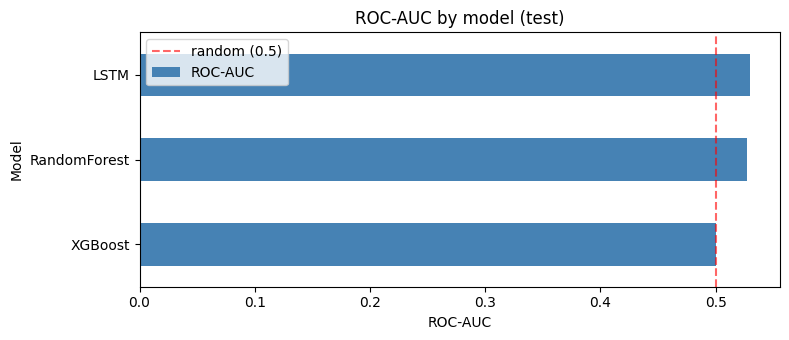

In [5]:
print(metrics_table.round(4))
ax = metrics_table["ROC-AUC"].sort_values().plot(kind="barh", figsize=(8, 3.5), color="steelblue")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.6, label="random (0.5)")
ax.set_title("ROC-AUC by model (test)"); ax.set_xlabel("ROC-AUC"); ax.legend()
plt.tight_layout(); plt.show()

**Reading the results.** Random Forest nominally wins, but the margin over the baseline is
within noise and the other models sit at 0.50–0.51. The honest headline is that **no model
extracts a meaningful directional edge** at the hourly horizon - the low signal-to-noise
found in EDA carries straight through to the models.

## 7. Interpretability (SHAP)

SHAP tells a consistent story across both tree models: predictions lean on **short-horizon
return and momentum features** (`log_return`, `roll_mean_3`, `momentum_3/7`) plus a recent
volatility term, and the direction of influence is **mean-reverting** - strong recent gains
nudge the model toward a *down* prediction, and vice versa. Random Forest and XGBoost broadly
agree on which features matter. The crucial qualifier is **magnitude**: because the models are
barely above chance, SHAP values are small and importance is spread thinly across many
correlated features. The local waterfall examples confirm this - individual contributions are
tiny and largely cancel, leaving predictions close to the base rate.

## 8. Uncertainty (MC-Dropout)

The MC-Dropout LSTM is **well-calibrated** (ECE ≈ 0.008): its stated confidence matches its
empirical accuracy, and predictive uncertainty is small and stable (mean std ≈ 0.019). But
calibration here means the model *correctly reports that it is unsure* - it is calibrated
around ~0.51 accuracy. Because the uncertainty spread is narrow rather than concentrated,
restricting to the most-confident predictions offers little room to improve accuracy. In
short: **the model knows what it doesn't know, and what it doesn't know is the next hour's
direction.**

## 9. Trading backtest

A statistical edge only matters if it survives trading. We compare the agent and a
model-signal strategy against **Buy & Hold** over the test window (the final ~15% of 2025,
which was itself a downtrend).

In [6]:
print(backtest_table.round(3))
backtest_table.round(3)

                Total return %  Sharpe  Max drawdown %  Win rate %
Strategy                                                          
Buy & Hold             -14.188  -2.138         -23.004      50.650
PPO agent              -16.506  -3.103         -21.757      51.720
XGBoost signal         -22.176  -4.220         -30.018      50.526


,Total return %,Sharpe,Max drawdown %,Win rate %
Strategy,,,,
Buy & Hold,-14.188,-2.138,-23.004,50.650
PPO agent,-16.506,-3.103,-21.757,51.720
XGBoost signal,-22.176,-4.220,-30.018,50.526


**Reading the backtest.** Every strategy lost money over the downtrending test window, and
**every Sharpe is negative** - so none beats Buy & Hold on a genuine risk-adjusted basis. The
PPO agent underperformed Buy & Hold despite being in the market only ~58% of the time, and the
XGBoost-signal strategy was worst. Where a defensive agent (e.g. CEM in earlier runs) helped,
it did so only by holding a lighter position and *losing less*, not by generating alpha - and
its large train-vs-test Sharpe gap was a textbook sign of overfitting / regime change.

## 10. Conclusions, limitations & future work

**Conclusions.** Across classical, tree-based, deep-learning and reinforcement-learning
methods, we find **no exploitable directional edge** in hourly BTC returns: the best classifier
(Random Forest, 0.527 AUC) barely beats a coin flip, the forecasters score below 50% on
direction, and every trading strategy underperforms Buy & Hold on a risk-adjusted basis. This
is consistent with the efficient-market view at this frequency and is a **credible,
well-supported result rather than a failure** - and the pipeline that produced it is fully
reproducible.

**Limitations.** A single asset and a single year (2025); a test window that happened to be a
downtrend, which flatters defensive strategies; transaction costs only approximated, with no
slippage or latency; hourly granularity that discards intra-hour information; and observed
overfitting in the RL agents (large train-vs-test Sharpe gap).

**Future work.** Add multiple assets and cross-asset features; incorporate order-book / on-chain
signals that may carry more information than price alone; use walk-forward retraining to track
regime shifts; replace binary long/flat with continuous position sizing; and give the RL agents
a cost-aware reward so policies are evaluated under realistic frictions.

## 11. Reproducibility & MLOps

This project is built as a **reproducible, modular pipeline** rather than a single notebook:

1. `01_data_processing` - download, validate, stationarity investigation, feature engineering, split.
2. `02_eda` - distributions, volatility, autocorrelation, stationarity, correlations.
3. `03_modelling` - trains **and saves every model to disk** (`train_or_load` pattern), logged to **MLflow**.
4. `04_analysis` - evaluation, SHAP, uncertainty, backtest; exports the result tables.
5. `05_final_report` - this standalone narrative.

Reproducibility guarantees: a single fixed **seed (42)**; **relative paths**; models persisted as
plain files (no dependence on ephemeral run-IDs), so *Restart & Run All* succeeds for any grader;
and every experiment tracked in MLflow (`mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db`).